# Limitation 1: Replacing Binary Blocking with Graded Shielding

## Problem statement

This notebook continues the existing minimal 2D Monte Carlo model and focuses on the first identified limitation:

> The blocking rule is binary and geometric. It does not represent graded transmission, diffraction, or reflected waves.

The aim of this iteration is not to make the model realistic in a CFD sense. It is to test whether the previously observed attraction survives when the hard on/off masking rule is replaced by a nearby but more graded and still interpretable alternative.


## Recap of the current model and the limitation under test

The current architecture is preserved:

- two parallel rectangular floating bodies in a 2D top view
- stochastic wave events in a source field
- distance-based attenuation
- side-normal impulse bookkeeping on inner and outer faces

Until now, shielding was all-or-nothing: if the segment from a source to a side sample crossed the other body, that contribution was set to zero.

That rule is transparent, but severe. It can overstate shielding because it treats a barely intersecting ray and a deeply traversing ray identically.


In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from float_sim.event_model import (
    ModelParameters,
    ShieldingModel,
    SourceField,
    event_count_from_source_density,
    plot_ensemble_metric,
    plot_geometry,
    plot_inner_outer_summary,
    plot_side_metrics,
    run_ensemble,
    run_gap_ensemble_sweep,
    simulate_batch,
    summarize_ensemble,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=3, suppress=True)


## Reduced alternative: graded shielding

Instead of deleting every occluded contribution, the new shielding rule uses the **segment length inside the blocker** as a proxy for how strongly the contribution is suppressed.

For intersecting source-to-side segments:

- `none`: transmission factor = `1`
- `binary`: transmission factor = `0`
- `graded`: transmission factor decreases smoothly with overlap length and approaches a configurable minimum transmission floor

This is still not a diffraction or reflection model. It is only a reduced control that asks whether the sign and magnitude of the effect depend strongly on the hardness of the shielding law.


In [2]:
BASE_SEED = 240
ENSEMBLE_REPEATS = 8
PARAMETER_REPEATS = 6
BASE_SOURCE_DENSITY = 8.0
GAPS = np.array([0.1, 0.3, 0.6, 1.0, 1.4, 1.8])
REFERENCE_GAPS = (0.3, 1.0, 1.8)

BASE_PARAMS = ModelParameters(
    body_length=3.0,
    body_width=0.4,
    domain_half_length=6.0,
    domain_half_width=4.0,
    attenuation_length=2.5,
    attenuation_power=0.0,
    mean_wave_amplitude=1.0,
    side_samples=17,
    mobility=0.002,
)
UNIFORM_FIELD = SourceField()

NO_SHIELDING = ShieldingModel.none()
BINARY_SHIELDING = ShieldingModel.binary()
GRADED_SHIELDING = ShieldingModel.graded(minimum_transmission=0.15, occlusion_decay_length=0.25)
SOFT_GRADED_SHIELDING = ShieldingModel.graded(minimum_transmission=0.30, occlusion_decay_length=0.40)


def events_for(params: ModelParameters, density: float = BASE_SOURCE_DENSITY) -> int:
    return event_count_from_source_density(density, params)


def gap_sweep(shielding_model: ShieldingModel, *, repeats: int = ENSEMBLE_REPEATS, seed: int = BASE_SEED):
    return run_gap_ensemble_sweep(
        gaps=GAPS,
        params=BASE_PARAMS,
        n_events=events_for(BASE_PARAMS),
        repeats=repeats,
        seed=seed,
        source_field=UNIFORM_FIELD,
        shielding_model=shielding_model,
    )


def ensemble_at_gap(
    gap: float,
    shielding_model: ShieldingModel,
    *,
    repeats: int = ENSEMBLE_REPEATS,
    seed: int = BASE_SEED,
):
    return run_ensemble(
        gap=gap,
        params=BASE_PARAMS,
        n_events=events_for(BASE_PARAMS),
        repeats=repeats,
        seed=seed,
        source_field=UNIFORM_FIELD,
        shielding_model=shielding_model,
    )


def shielding_parameter_slice(values, *, parameter: str, gaps=REFERENCE_GAPS, repeats: int = PARAMETER_REPEATS):
    rows = []
    for value_index, value in enumerate(values):
        if parameter == "minimum_transmission":
            shielding = ShieldingModel.graded(
                minimum_transmission=float(value),
                occlusion_decay_length=GRADED_SHIELDING.occlusion_decay_length,
            )
        elif parameter == "occlusion_decay_length":
            shielding = ShieldingModel.graded(
                minimum_transmission=GRADED_SHIELDING.minimum_transmission,
                occlusion_decay_length=float(value),
            )
        else:
            raise ValueError(parameter)

        for gap_index, gap in enumerate(gaps):
            summary = summarize_ensemble(
                run_ensemble(
                    gap=gap,
                    params=BASE_PARAMS,
                    n_events=events_for(BASE_PARAMS),
                    repeats=repeats,
                    seed=BASE_SEED + 100 * value_index + 11 * gap_index,
                    source_field=UNIFORM_FIELD,
                    shielding_model=shielding,
                )
            )
            rows.append((float(value), float(gap), summary))
    return rows


def plot_parameter_slice(ax, rows, *, xlabel: str, title: str):
    colors = {0.3: "#e76f51", 1.0: "#457b9d", 1.8: "#1d3557"}
    for gap in REFERENCE_GAPS:
        subset = [(value, summary) for value, row_gap, summary in rows if np.isclose(row_gap, gap)]
        xs = np.array([value for value, _ in subset], dtype=float)
        ys = np.array([summary.mean_gap_closing_force for _, summary in subset], dtype=float)
        es = np.array([summary.sem_gap_closing_force for _, summary in subset], dtype=float)
        ax.plot(xs, ys, marker="o", color=colors[gap], label=f"gap = {gap:.1f}")
        ax.fill_between(xs, ys - es, ys + es, color=colors[gap], alpha=0.15)
    ax.axhline(0.0, color="0.4", linestyle="--", linewidth=1.0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mean gap-closing force")
    ax.set_title(title)
    ax.legend(loc="best")


def compact_summary_table(summaries):
    rows = []
    for summary in summaries:
        rows.append(
            {
                "gap": round(summary.gap, 2),
                "force": round(summary.mean_gap_closing_force, 2),
                "sem": round(summary.sem_gap_closing_force, 2),
                "system_net": round(summary.mean_system_net_force_y, 2),
                "inner_impulse": round(summary.mean_inner_impulse, 2),
                "outer_impulse": round(summary.mean_outer_impulse, 2),
            }
        )
    return rows


## Ensemble methodology

Each configuration is rerun over multiple deterministic seeds. The primary observables are:

- mean gap-closing force
- uncertainty across runs (SEM bands)
- mean system net lateral force as a symmetry control
- inner-side versus outer-side hit counts
- inner-side versus outer-side cumulative impulse


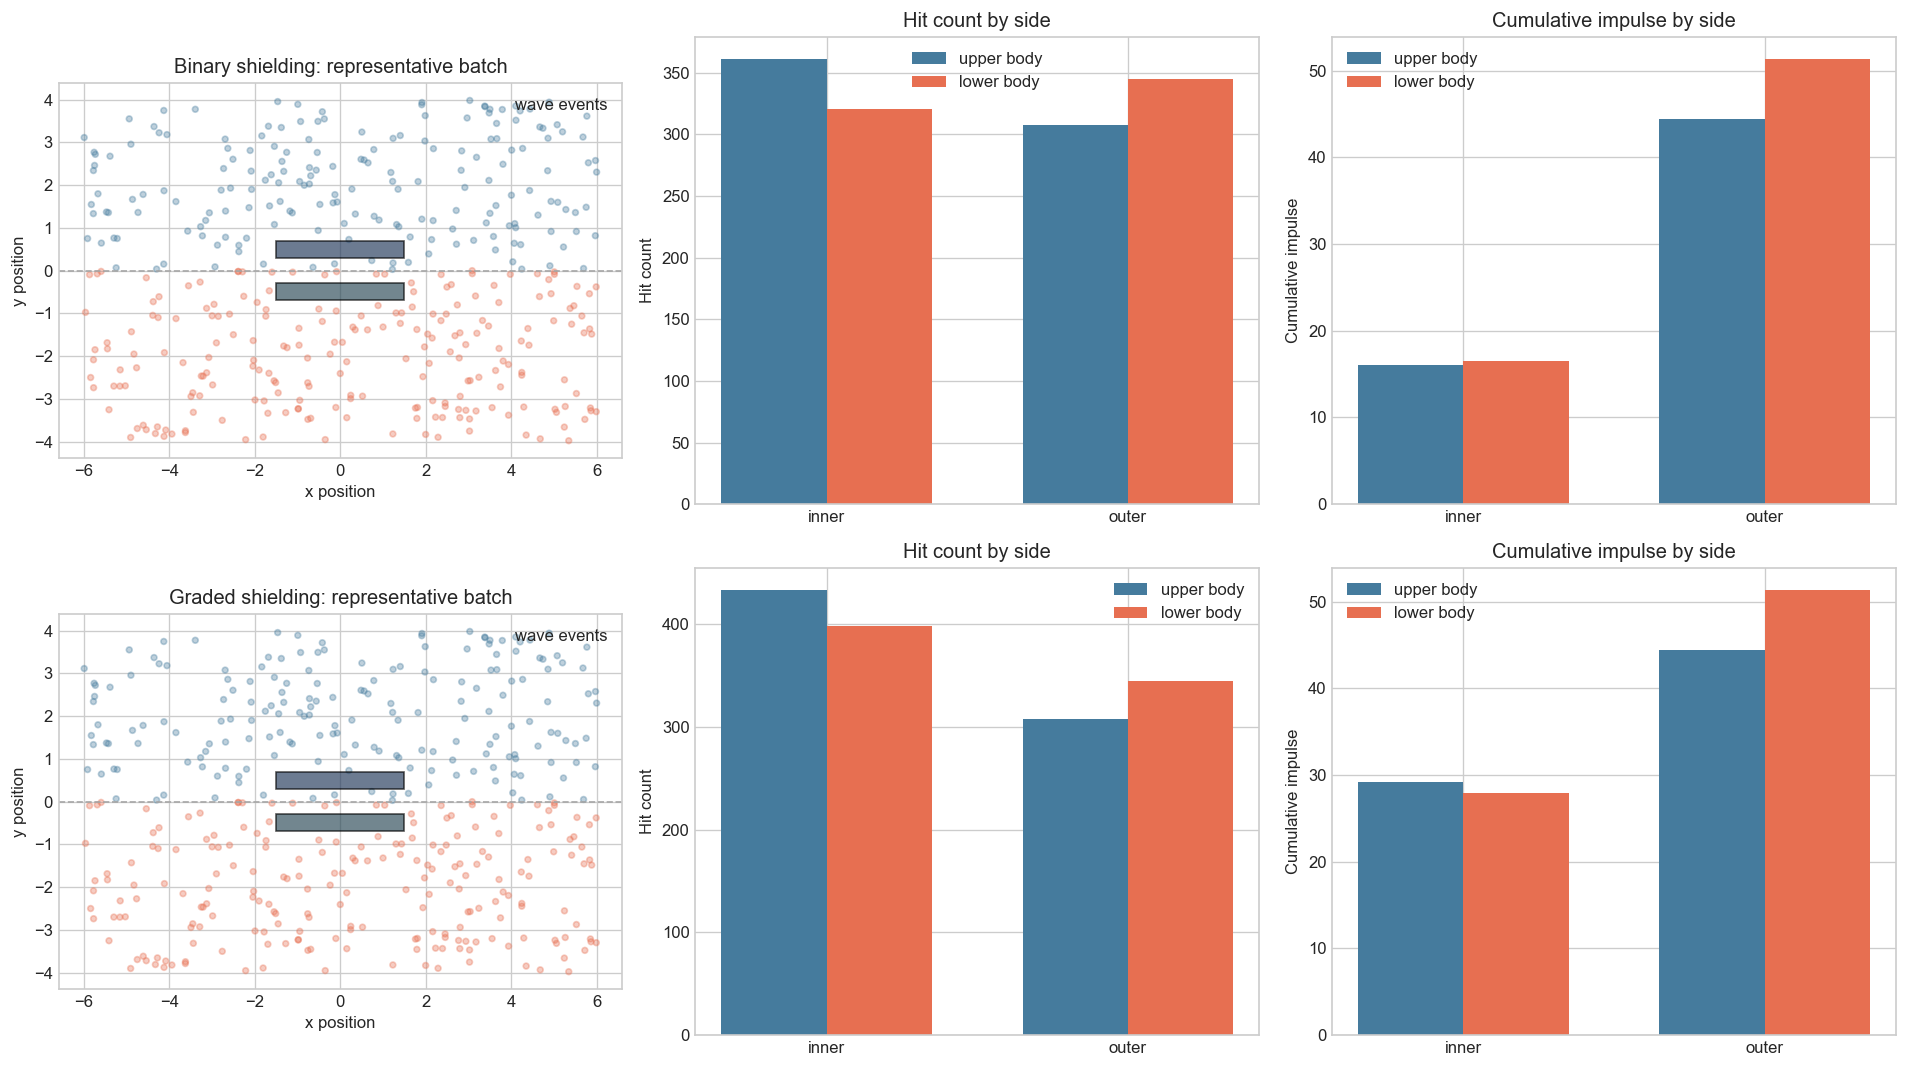

In [3]:
binary_batch = simulate_batch(
    gap=0.6,
    params=BASE_PARAMS,
    rng=np.random.default_rng(BASE_SEED),
    n_events=events_for(BASE_PARAMS),
    source_field=UNIFORM_FIELD,
    shielding_model=BINARY_SHIELDING,
)
graded_batch = simulate_batch(
    gap=0.6,
    params=BASE_PARAMS,
    rng=np.random.default_rng(BASE_SEED),
    n_events=events_for(BASE_PARAMS),
    source_field=UNIFORM_FIELD,
    shielding_model=GRADED_SHIELDING,
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_geometry(axes[0, 0], binary_batch, max_events=400)
plot_side_metrics(axes[0, 1], binary_batch, metric="hits")
plot_side_metrics(axes[0, 2], binary_batch, metric="impulse")
plot_geometry(axes[1, 0], graded_batch, max_events=400)
plot_side_metrics(axes[1, 1], graded_batch, metric="hits")
plot_side_metrics(axes[1, 2], graded_batch, metric="impulse")
axes[0, 0].set_title("Binary shielding: representative batch")
axes[1, 0].set_title("Graded shielding: representative batch")
fig.tight_layout()
plt.show()


## Results: force versus gap under different shielding laws

The first comparison is deliberately direct: no shielding, the original binary rule, and two graded variants with different softness.


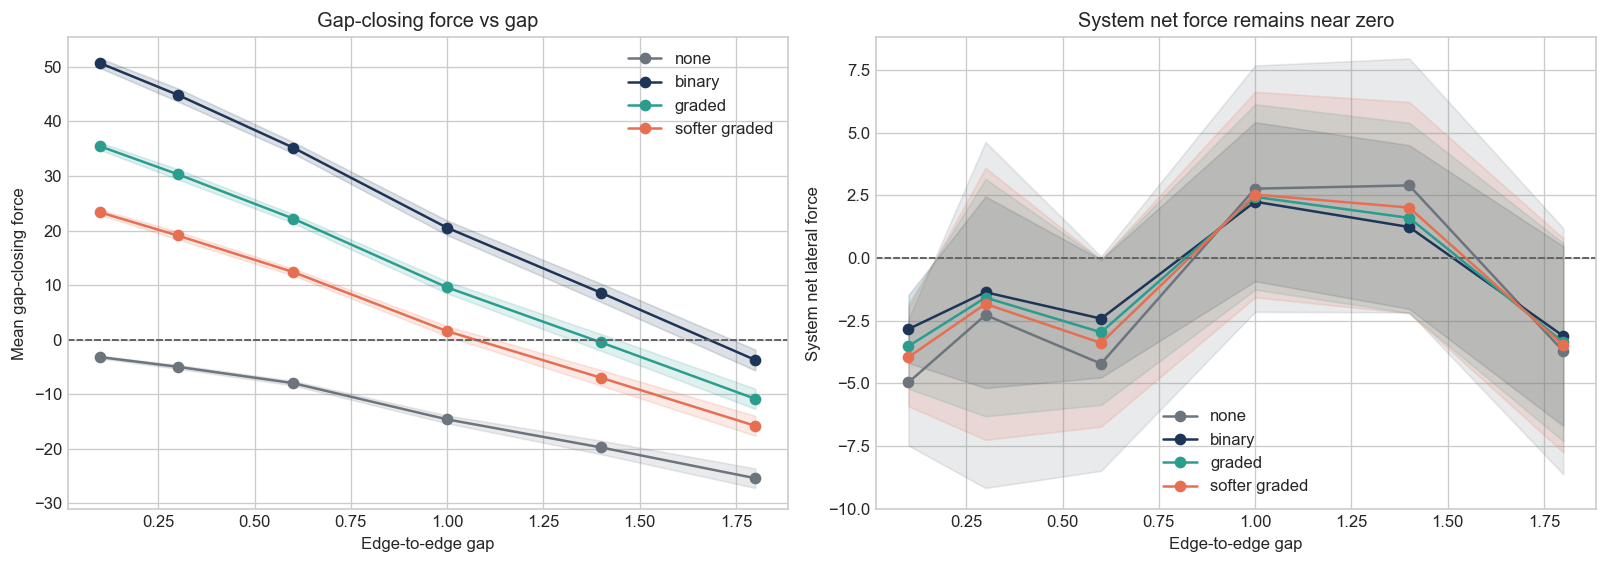

none
{'gap': 0.1, 'force': -3.21, 'sem': 0.25, 'system_net': -4.95, 'inner_impulse': 58.27, 'outer_impulse': 55.06}
{'gap': 0.3, 'force': -4.98, 'sem': 0.36, 'system_net': -2.27, 'inner_impulse': 58.88, 'outer_impulse': 53.9}
{'gap': 0.6, 'force': -7.98, 'sem': 0.42, 'system_net': -4.21, 'inner_impulse': 59.96, 'outer_impulse': 51.98}
{'gap': 1.0, 'force': -14.62, 'sem': 0.73, 'system_net': 2.77, 'inner_impulse': 63.96, 'outer_impulse': 49.34}
{'gap': 1.4, 'force': -19.77, 'sem': 1.24, 'system_net': 2.9, 'inner_impulse': 66.2, 'outer_impulse': 46.43}
{'gap': 1.8, 'force': -25.4, 'sem': 1.79, 'system_net': -3.71, 'inner_impulse': 67.26, 'outer_impulse': 41.85}

binary
{'gap': 0.1, 'force': 50.65, 'sem': 0.89, 'system_net': -2.83, 'inner_impulse': 4.41, 'outer_impulse': 55.06}
{'gap': 0.3, 'force': 44.88, 'sem': 1.19, 'system_net': -1.36, 'inner_impulse': 9.02, 'outer_impulse': 53.9}
{'gap': 0.6, 'force': 35.2, 'sem': 1.04, 'system_net': -2.41, 'inner_impulse': 16.78, 'outer_impulse': 51

In [4]:
no_shielding_sweep = gap_sweep(NO_SHIELDING)
binary_sweep = gap_sweep(BINARY_SHIELDING)
graded_sweep = gap_sweep(GRADED_SHIELDING)
soft_graded_sweep = gap_sweep(SOFT_GRADED_SHIELDING)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
plot_ensemble_metric(axes[0], no_shielding_sweep, metric="gap_closing_force", label="none", color="#6c757d")
plot_ensemble_metric(axes[0], binary_sweep, metric="gap_closing_force", label="binary", color="#1d3557")
plot_ensemble_metric(axes[0], graded_sweep, metric="gap_closing_force", label="graded", color="#2a9d8f")
plot_ensemble_metric(axes[0], soft_graded_sweep, metric="gap_closing_force", label="softer graded", color="#e76f51")
axes[0].set_title("Gap-closing force vs gap")

plot_ensemble_metric(axes[1], no_shielding_sweep, metric="system_net_force", label="none", color="#6c757d")
plot_ensemble_metric(axes[1], binary_sweep, metric="system_net_force", label="binary", color="#1d3557")
plot_ensemble_metric(axes[1], graded_sweep, metric="system_net_force", label="graded", color="#2a9d8f")
plot_ensemble_metric(axes[1], soft_graded_sweep, metric="system_net_force", label="softer graded", color="#e76f51")
axes[1].set_title("System net force remains near zero")

fig.tight_layout()
plt.show()

for label, summaries in [
    ("none", no_shielding_sweep),
    ("binary", binary_sweep),
    ("graded", graded_sweep),
    ("softer graded", soft_graded_sweep),
]:
    print(label)
    for row in compact_summary_table(summaries):
        print(row)
    print()


## Inner versus outer diagnostics

If graded shielding matters, the main change should be on the inner side: occluded contributions should be reduced, but not deleted outright. The next plots compare no shielding, binary shielding, and the default graded shielding.


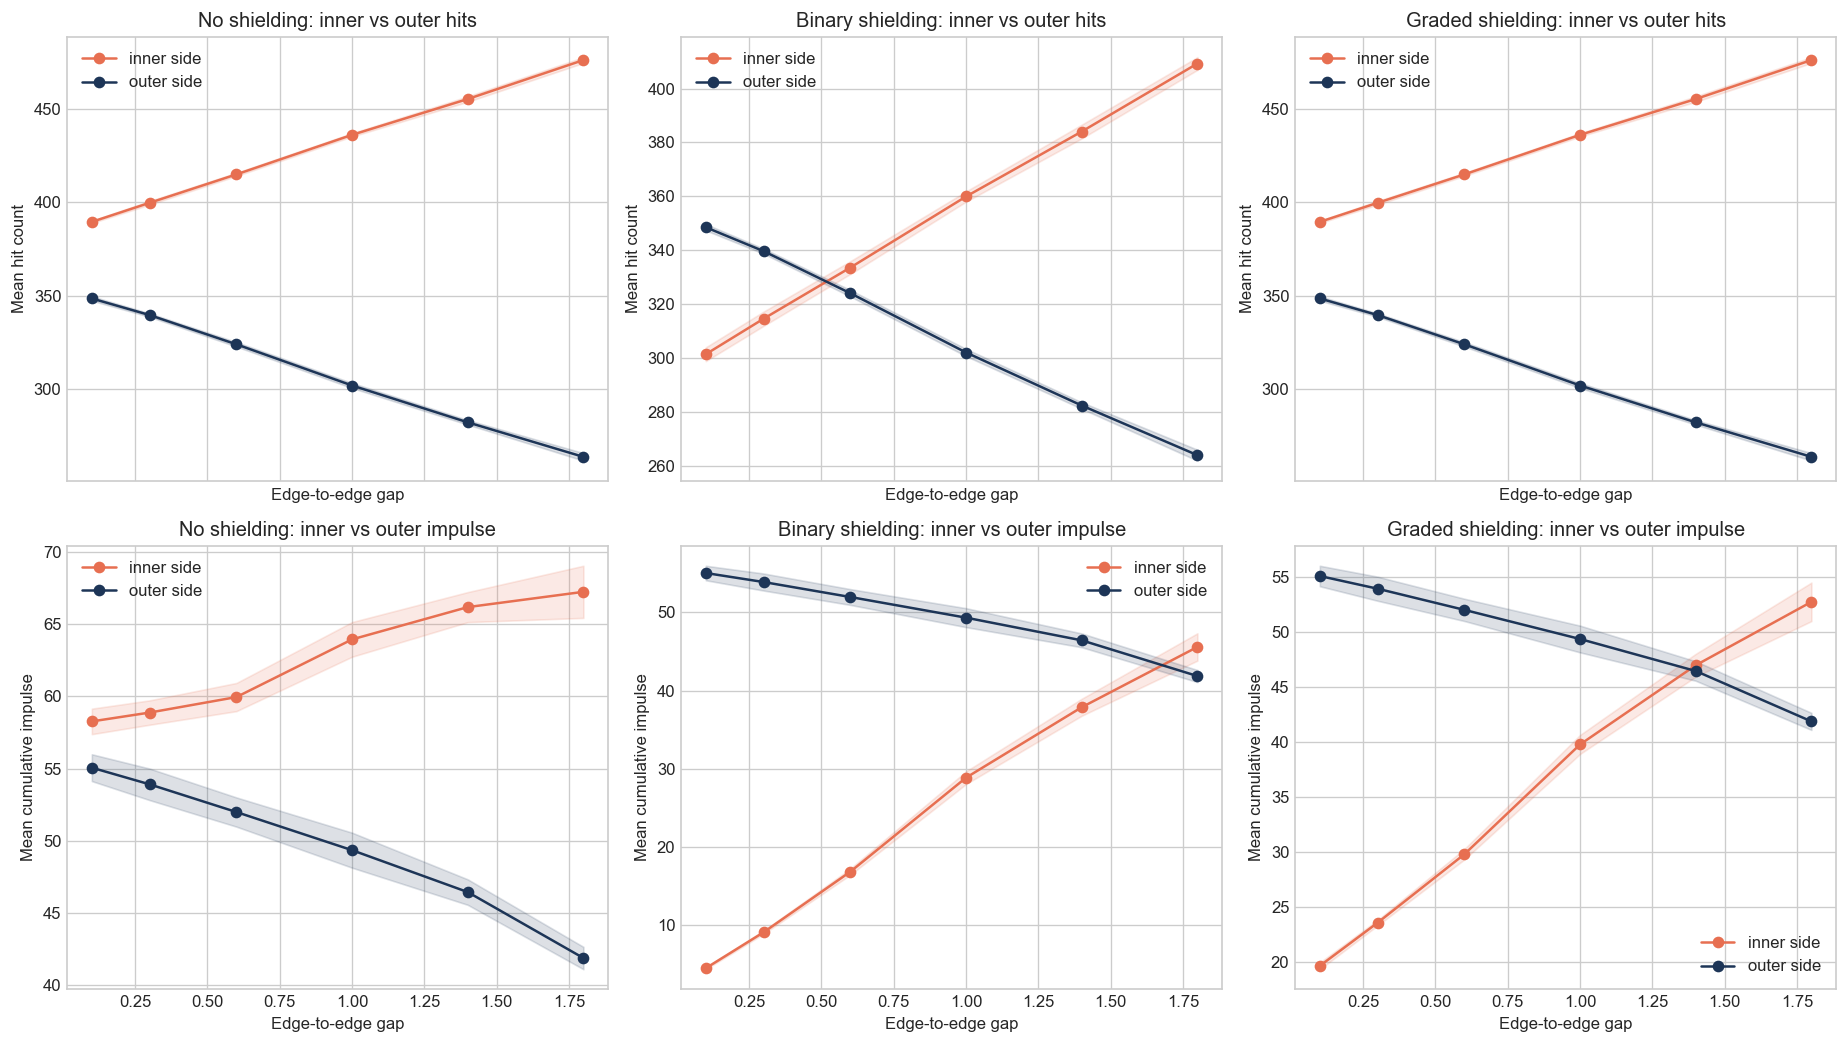

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.8), sharex=True)

plot_inner_outer_summary(axes[0, 0], no_shielding_sweep, metric="hits")
axes[0, 0].set_title("No shielding: inner vs outer hits")
plot_inner_outer_summary(axes[0, 1], binary_sweep, metric="hits")
axes[0, 1].set_title("Binary shielding: inner vs outer hits")
plot_inner_outer_summary(axes[0, 2], graded_sweep, metric="hits")
axes[0, 2].set_title("Graded shielding: inner vs outer hits")

plot_inner_outer_summary(axes[1, 0], no_shielding_sweep, metric="impulse")
axes[1, 0].set_title("No shielding: inner vs outer impulse")
plot_inner_outer_summary(axes[1, 1], binary_sweep, metric="impulse")
axes[1, 1].set_title("Binary shielding: inner vs outer impulse")
plot_inner_outer_summary(axes[1, 2], graded_sweep, metric="impulse")
axes[1, 2].set_title("Graded shielding: inner vs outer impulse")

fig.tight_layout()
plt.show()


/var/folders/6f/8z2mypfj3zb8dbz2bvkp7yn80000gn/T/ipykernel_41082/4076678637.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(force_data, labels=labels, showmeans=True)
/var/folders/6f/8z2mypfj3zb8dbz2bvkp7yn80000gn/T/ipykernel_41082/4076678637.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(imbalance_data, labels=labels, showmeans=True)


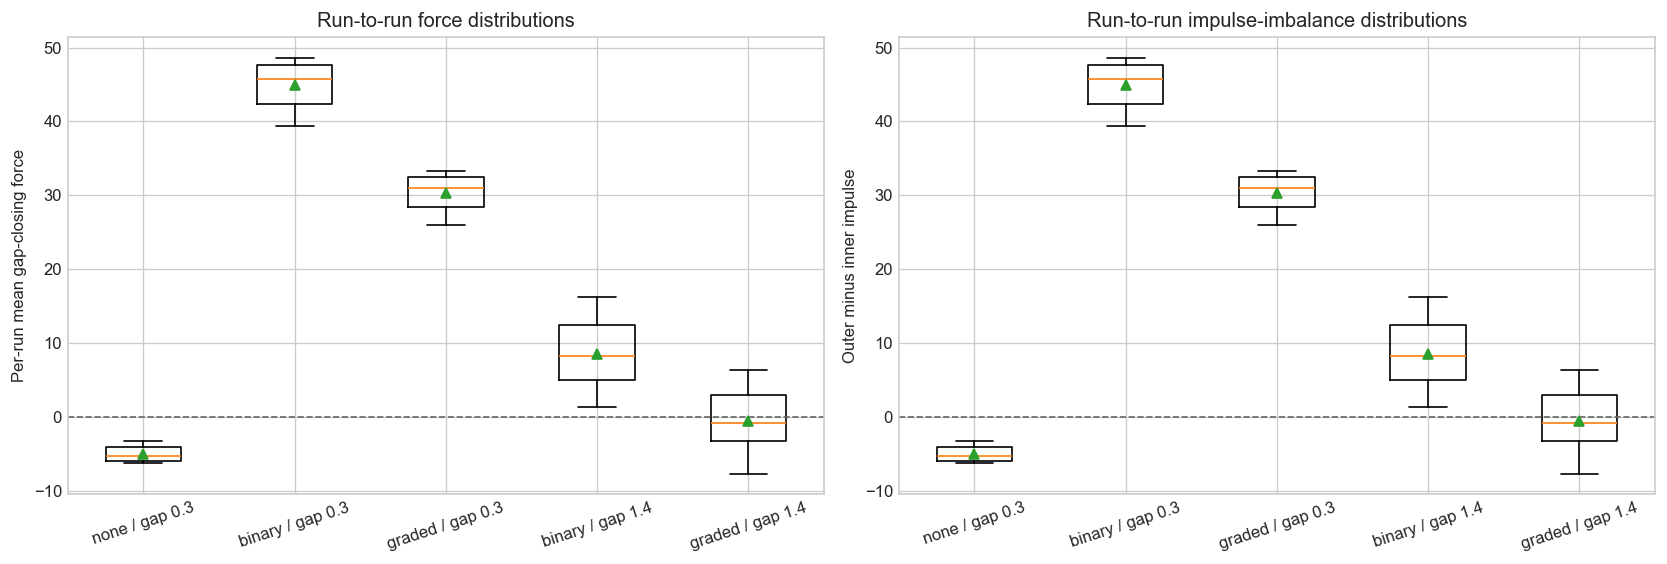

In [6]:
distribution_cases = {
    "none / gap 0.3": ensemble_at_gap(0.3, NO_SHIELDING),
    "binary / gap 0.3": ensemble_at_gap(0.3, BINARY_SHIELDING),
    "graded / gap 0.3": ensemble_at_gap(0.3, GRADED_SHIELDING),
    "binary / gap 1.4": ensemble_at_gap(1.4, BINARY_SHIELDING),
    "graded / gap 1.4": ensemble_at_gap(1.4, GRADED_SHIELDING),
}

labels = list(distribution_cases)
force_data = [[record.mean_gap_closing_force for record in distribution_cases[label]] for label in labels]
imbalance_data = [[record.impulse_imbalance for record in distribution_cases[label]] for label in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot(force_data, labels=labels, showmeans=True)
axes[0].axhline(0.0, color="0.4", linestyle="--", linewidth=1.0)
axes[0].set_ylabel("Per-run mean gap-closing force")
axes[0].set_title("Run-to-run force distributions")
axes[0].tick_params(axis="x", rotation=18)

axes[1].boxplot(imbalance_data, labels=labels, showmeans=True)
axes[1].axhline(0.0, color="0.4", linestyle="--", linewidth=1.0)
axes[1].set_ylabel("Outer minus inner impulse")
axes[1].set_title("Run-to-run impulse-imbalance distributions")
axes[1].tick_params(axis="x", rotation=18)

fig.tight_layout()
plt.show()


## Sensitivity of the graded shielding rule itself

The default graded rule still has two free parameters:

- `minimum_transmission`: the residual transmission for strongly occluded rays
- `occlusion_decay_length`: how quickly transmission drops with overlap length inside the blocker

If attraction survives only when these parameters are tuned close to binary masking, that should be stated plainly.


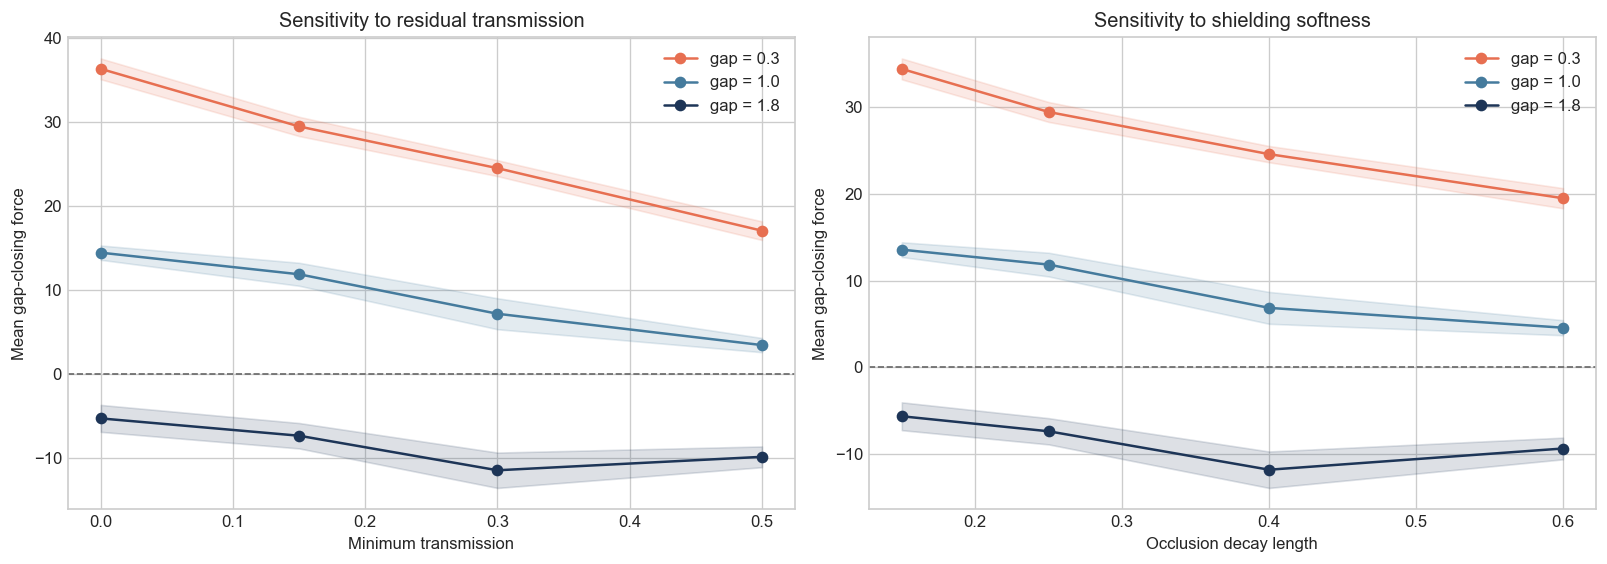

In [7]:
minimum_transmission_slice = shielding_parameter_slice(
    [0.0, 0.15, 0.30, 0.50],
    parameter="minimum_transmission",
)
decay_length_slice = shielding_parameter_slice(
    [0.15, 0.25, 0.40, 0.60],
    parameter="occlusion_decay_length",
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
plot_parameter_slice(
    axes[0],
    minimum_transmission_slice,
    xlabel="Minimum transmission",
    title="Sensitivity to residual transmission",
)
plot_parameter_slice(
    axes[1],
    decay_length_slice,
    xlabel="Occlusion decay length",
    title="Sensitivity to shielding softness",
)
fig.tight_layout()
plt.show()


## Interpretation of this limitation study

The main pattern in the default stress test is:

- no shielding remains repulsive across the tested gap range
- binary shielding produces the strongest attraction and keeps it positive to larger gaps
- graded shielding still produces attraction at small and intermediate gaps, but the effect is materially weaker
- the sign changes earlier under graded shielding than under binary shielding

That matters because it narrows the claim.

The earlier attraction result is **not** merely a consequence of using the word “blocking”. It partly survives a nonbinary alternative. But it is also clearly amplified by the harshness of the binary rule, so the shielding law remains a decisive modeling choice rather than a minor detail.


## What this does and does not fix

This iteration addresses the first limitation only partially.

What improved:

- the model no longer requires an all-or-nothing shielding decision
- the effect of shielding hardness is now explicit and sweepable
- the notebook can distinguish stronger claims that survive graded transmission from those that only survive binary masking

What remains unresolved:

- the graded rule is still geometric and imposed, not derived from wave physics
- there is still no explicit diffraction, no reflection term, and no self-consistent wave field
- the other listed limitations remain in place and should be treated separately


## Recommended next step

The next sensible move within this same limitation is to add one more reduced alternative beside graded transmission: a simple reflected or diffracted residual term for occluded rays, then rerun the same ensemble notebook.

That would tell us whether the surviving attraction is robust to more than one nonbinary shielding law, or whether it depends mainly on the particular graded transmission formula used here.
